# FEMA Cost Recovery Forecast — Exploratory Data Analysis

- This Eda explores three FEMA datasets:

1. `declaration.csv`
2. `public_assistance.csv`
3. `disaster_summaries.csv`

- The aim of this EDA is to understand disaster patterns, declaration timing, public assistance funding, and recovery-related financial indicators - before preprocessing, feature engineering, and modelling.

# STEP 1 - Setup & Imports

In [9]:

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Define data paths
DATA_RAW = os.path.join("..", "data", "raw")
DATA_PROCESSED = os.path.join("..", "data", "Processed")

os.makedirs(DATA_PROCESSED, exist_ok=True)

### STEP 2 - Loading the Data


In [10]:
declarations = pd.read_csv(os.path.join(DATA_RAW, "declarations.csv"), parse_dates=["declarationDate", "incidentBeginDate", "incidentEndDate"])
disaster_summaries = pd.read_csv(os.path.join(DATA_RAW, "disaster_summaries.csv"))
public_assistance = pd.read_csv(os.path.join(DATA_RAW, "public_assistance.csv"))

In [11]:
# STEP 2a - Data Overview

for name, df in [
    ("declarations", declarations),
    ("public_assistance", public_assistance),
    ("disaster_summaries", disaster_summaries)
]:
    print(f"{name:<22} {df.shape[0]:>8} rows {df.shape[1]:>3} cols")

declarations              69905 rows  10 cols
public_assistance        812867 rows   8 cols
disaster_summaries         3945 rows  11 cols


In [12]:
# STEP 2b - Data Inspection

for name, df in [
    ("declarations", declarations),
    ("public_assistance", public_assistance),
    ("disaster_summaries", disaster_summaries)
]:
    print("\n" + "="*60)
    print(name.upper())
    print("="*60)
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isnull().sum())
    display(df.head()) 


DECLARATIONS
disasterNumber                            int64
state                                       str
declarationType                             str
incidentType                                str
declarationDate             datetime64[us, UTC]
incidentBeginDate           datetime64[us, UTC]
incidentEndDate             datetime64[us, UTC]
fyDeclared                                int64
designatedArea                              str
declarationRequestNumber                  int64
dtype: object

Missing values:
disasterNumber                0
state                         0
declarationType               0
incidentType                  0
declarationDate               0
incidentBeginDate             0
incidentEndDate             534
fyDeclared                    0
designatedArea                0
declarationRequestNumber      0
dtype: int64


,disasterNumber,state,declarationType,incidentType,declarationDate,incidentBeginDate,incidentEndDate,fyDeclared,designatedArea,declarationRequestNumber
0,3610,PR,EM,Severe Storm,2024-08-13 00:00:00+00:00,2024-08-13 00:00:00+00:00,2024-08-16 00:00:00+00:00,2024,Adjuntas (Municipio),24124
1,5529,OR,FM,Fire,2024-08-09 00:00:00+00:00,2024-08-08 00:00:00+00:00,NaT,2024,Washington (County),24122
2,5528,OR,FM,Fire,2024-08-06 00:00:00+00:00,2024-08-04 00:00:00+00:00,NaT,2024,Jefferson (County),24116
3,5527,OR,FM,Fire,2024-08-02 00:00:00+00:00,2024-08-02 00:00:00+00:00,NaT,2024,Deschutes (County),24111
4,3610,PR,EM,Severe Storm,2024-08-13 00:00:00+00:00,2024-08-13 00:00:00+00:00,2024-08-16 00:00:00+00:00,2024,Aguada (Municipio),24124



PUBLIC_ASSISTANCE
disasterNumber             int64
stateAbbreviation            str
projectAmount            float64
federalShareObligated    float64
totalObligated           float64
projectSize                  str
damageCategoryCode           str
applicationTitle             str
dtype: object

Missing values:
disasterNumber           0
stateAbbreviation        0
projectAmount            0
federalShareObligated    0
totalObligated           0
projectSize              0
damageCategoryCode       0
applicationTitle         0
dtype: int64


,disasterNumber,stateAbbreviation,projectAmount,federalShareObligated,totalObligated,projectSize,damageCategoryCode,applicationTitle
0,1361,WA,1203.00,902.25,957.10,Small,B,(PW# 81) INSPECTION OF TOWN BUILDINGS & UTILITIES
1,1603,LA,15156787.07,15156787.07,15312129.35,Large,E,(PW# 18773) CONTENTS ROLLUP-MULTIPLE SITES; MU...
2,3582,MS,159127.24,119345.43,119345.43,Small,B,MS- State Department of Health EPM-Period 1 - ...
3,1817,WA,6847.49,5135.62,5135.62,Small,C,(PW# 537) SEBC005 - S. Emery Ave. Road/Shoulde...
4,3582,MS,118703.32,89027.49,89027.49,Small,B,MS- State Department of Health EPM-Period 3 - ...



DISASTER_SUMMARIES
disasterNumber                  int64
totalNumberIaApproved         float64
totalAmountIhpApproved        float64
totalAmountHaApproved         float64
totalAmountOnaApproved        float64
totalObligatedAmountPa        float64
totalObligatedAmountCatAb     float64
totalObligatedAmountCatC2g    float64
totalObligatedAmountHmgp      float64
paLoadDate                        str
iaLoadDate                        str
dtype: object

Missing values:
disasterNumber                   0
totalNumberIaApproved         3339
totalAmountIhpApproved        3339
totalAmountHaApproved         3395
totalAmountOnaApproved        3341
totalObligatedAmountPa         956
totalObligatedAmountCatAb     1217
totalObligatedAmountCatC2g    2389
totalObligatedAmountHmgp      1102
paLoadDate                     956
iaLoadDate                    3339
dtype: int64


,disasterNumber,totalNumberIaApproved,totalAmountIhpApproved,totalAmountHaApproved,totalAmountOnaApproved,totalObligatedAmountPa,totalObligatedAmountCatAb,totalObligatedAmountCatC2g,totalObligatedAmountHmgp,paLoadDate,iaLoadDate
0,3601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1802,NaN,NaN,NaN,NaN,1.881275e+07,1.342309e+07,4.869890e+06,2710679.0,2026-02-06T00:00:00.000Z,NaN
3,1292,NaN,NaN,NaN,NaN,2.981058e+08,1.436027e+08,1.504852e+08,67665966.0,2026-02-06T00:00:00.000Z,NaN
4,3163,NaN,NaN,NaN,NaN,5.380816e+06,5.369404e+06,NaN,NaN,2026-02-06T00:00:00.000Z,NaN


### STEP 3 - Convert Date Columns


In [ ]:
#  date columns
declaration_date_cols = [
    "declarationDate",
    "incidentBeginDate",
    "incidentEndDate",
    "paLoadDate",
    "iaLoadDate"
]

for col in declaration_date_cols:
    if col in declarations.columns:
        declarations[col] = pd.to_datetime(declarations[col], errors="coerce")

### STEP 4 - Declarations Dataset Analysis


In [14]:
declarations.head()
print(f"Shape: {declarations.shape}")
print(declarations.dtypes)
print(declarations.isnull().sum())

Shape: (69905, 10)
disasterNumber                            int64
state                                       str
declarationType                             str
incidentType                                str
declarationDate             datetime64[us, UTC]
incidentBeginDate           datetime64[us, UTC]
incidentEndDate             datetime64[us, UTC]
fyDeclared                                int64
designatedArea                              str
declarationRequestNumber                  int64
dtype: object
disasterNumber                0
state                         0
declarationType               0
incidentType                  0
declarationDate               0
incidentBeginDate             0
incidentEndDate             534
fyDeclared                    0
designatedArea                0
declarationRequestNumber      0
dtype: int64


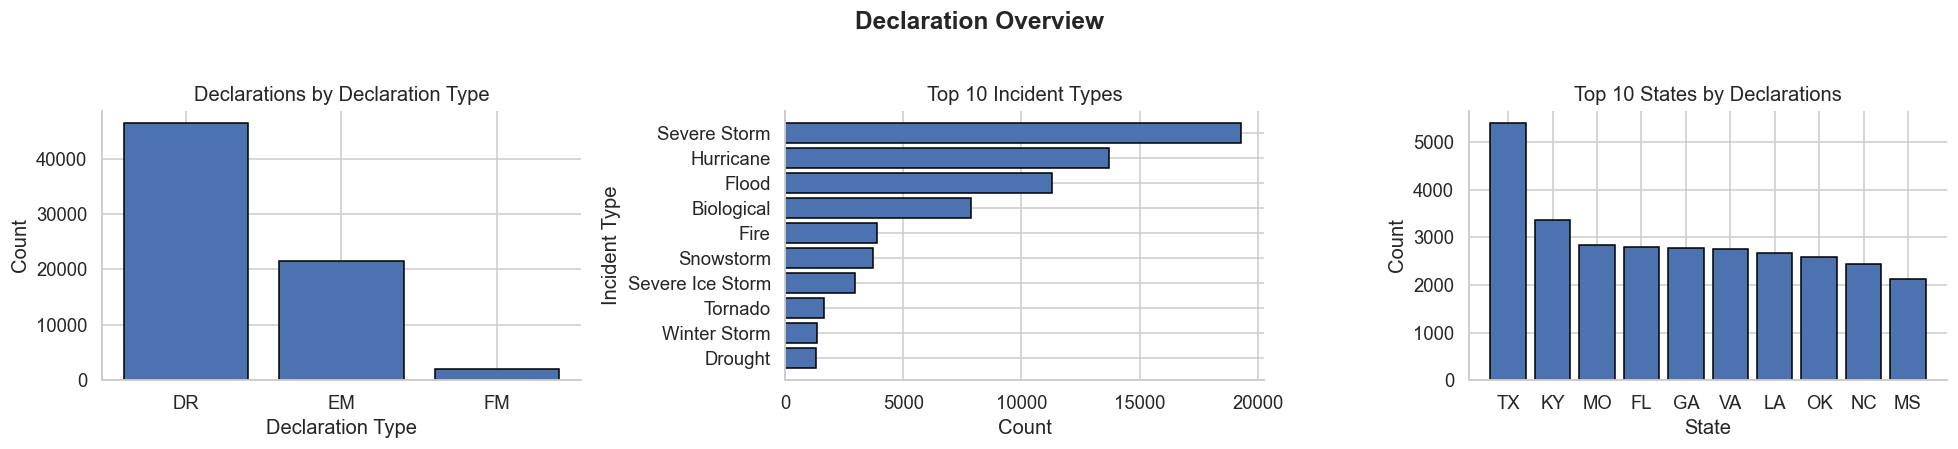

In [15]:
# STEP 4a - Declaration Type, Incident Type and State Distribution

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Declaration type
if "declarationType" in declarations.columns:
    declaration_type_counts = declarations["declarationType"].value_counts()
    axes[0].bar(declaration_type_counts.index, declaration_type_counts.values, edgecolor="black")
    axes[0].set(title="Declarations by Declaration Type", xlabel="Declaration Type", ylabel="Count")

# Top incident types
if "incidentType" in declarations.columns:
    incident_counts = declarations["incidentType"].value_counts().head(10)
    axes[1].barh(incident_counts.index, incident_counts.values, edgecolor="black")
    axes[1].set(title="Top 10 Incident Types", xlabel="Count", ylabel="Incident Type")
    axes[1].invert_yaxis()

# Top states
if "state" in declarations.columns:
    state_counts = declarations["state"].value_counts().head(10)
    axes[2].bar(state_counts.index, state_counts.values, edgecolor="black")
    axes[2].set(title="Top 10 States by Declarations", xlabel="State", ylabel="Count")

plt.suptitle("Declaration Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

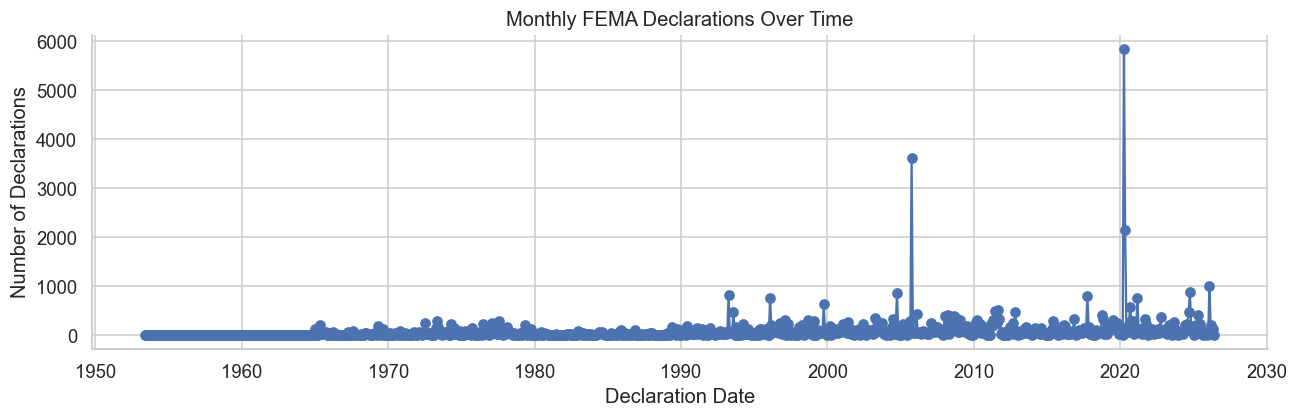

In [16]:
# STEP 4b - Declaration Trends Over Time

if "declarationDate" in declarations.columns:
    monthly_declarations = (
        declarations
        .set_index("declarationDate")
        .resample("ME")
        .size()
        .reset_index(name="declarations")
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(monthly_declarations["declarationDate"], monthly_declarations["declarations"], marker="o")
    ax.set(
        title="Monthly FEMA Declarations Over Time",
        xlabel="Declaration Date",
        ylabel="Number of Declarations"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# STEP 4c - Incident Duration and Declaration Delay

# Create duration days:
#  how long disaster last

# example: 

# incident Begin : 2023-08-01
# incident End:    2023-08-15

# Duration = 14 days          

if {"incidentBeginDate", "incidentEndDate"}.issubset(declarations.columns):
    declarations["incident_duration_days"] = (
        declarations["incidentEndDate"] - declarations["incidentBeginDate"]
    ).dt.days
 
# create declaration Day
# how long dif Fema take to officially declare the disaster after it started

# Example:

# incident Begin : 2023-08-01
# Declaration    : 2023-08-01

# delay = 9 days


if {"declarationDate", "incidentBeginDate"}.issubset(declarations.columns):
    declarations["declaration_delay_days"] = (
        declarations["declarationDate"] - declarations["incidentBeginDate"]
    ).dt.days

# step 6a -descriptive summary

temporal_cols = [
    "incident_duration_days",
    "declaration_delay_days"
]

for col in temporal_cols:
    print(f"{col} summary:")
    print(declarations[col].describe())
    print("declarations[col].skew():", declarations[col].skew())




incident_duration_days summary:
count    69371.000000
mean       156.364965
std        377.290330
min         -7.000000
25%          3.000000
50%         13.000000
75%         39.000000
max       5117.000000
Name: incident_duration_days, dtype: float64
declarations[col].skew(): 2.4334710962673447
declaration_delay_days summary:
count    69905.000000
mean        25.479022
std         32.336160
min       -266.000000
25%          2.000000
50%         11.000000
75%         48.000000
max       2671.000000
Name: declaration_delay_days, dtype: float64
declarations[col].skew(): 9.41174960293306


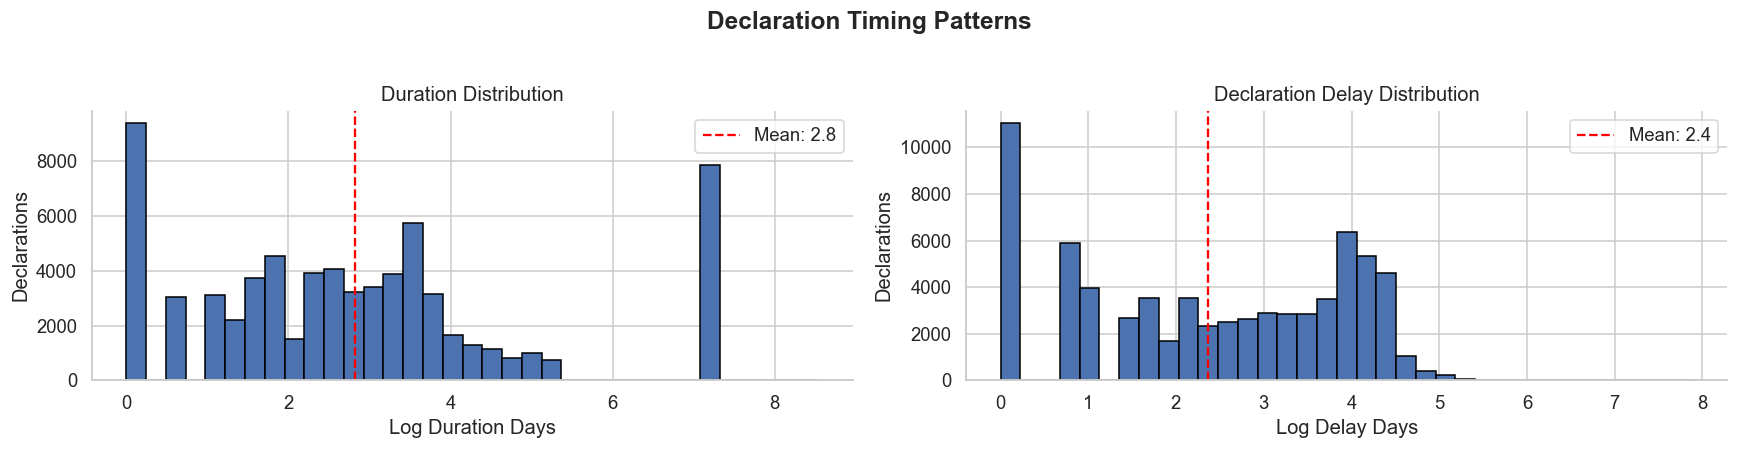

In [30]:


# Remove impossible negative values
declarations["incident_duration_days"] = declarations["incident_duration_days"].clip(lower=0)
declarations["declaration_delay_days"] = declarations["declaration_delay_days"].clip(lower=0)

# Safe log transform
declarations["log_incident_duration_days"] = np.log1p(declarations["incident_duration_days"])
declarations["log_declaration_delay_days"] = np.log1p(declarations["declaration_delay_days"])

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Duration plot
data1 = declarations["log_incident_duration_days"].dropna()
axes[0].hist(data1, bins=35, edgecolor="black")
axes[0].axvline(data1.mean(), color="red", linestyle="dashed", label=f"Mean: {data1.mean():.1f}")
axes[0].set(title="Duration Distribution", xlabel="Log Duration Days", ylabel="Declarations")
axes[0].legend()

# Delay plot
data2 = declarations["log_declaration_delay_days"].dropna()
axes[1].hist(data2, bins=35, edgecolor="black")
axes[1].axvline(data2.mean(), color="red", linestyle="dashed", label=f"Mean: {data2.mean():.1f}")
axes[1].set(title="Declaration Delay Distribution", xlabel="Log Delay Days", ylabel="Declarations")
axes[1].legend()

plt.suptitle("Declaration Timing Patterns", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### STEP 5 - Public Assistance Dataset Analysis

In [23]:
public_assistance.head()
print(f"Shape: {public_assistance.shape}")
print(public_assistance.dtypes)
print(public_assistance.isnull().sum())

Shape: (812867, 8)
disasterNumber             int64
stateAbbreviation            str
projectAmount            float64
federalShareObligated    float64
totalObligated           float64
projectSize                  str
damageCategoryCode           str
applicationTitle             str
dtype: object
disasterNumber           0
stateAbbreviation        0
projectAmount            0
federalShareObligated    0
totalObligated           0
projectSize              0
damageCategoryCode       0
applicationTitle         0
dtype: int64


In [31]:
# check for skewness in  amount_colums
public_assistance[
    [
        "projectAmount",
        "totalObligated",
        "federalShareObligated"
    ]
].skew()


projectAmount            309.987882
totalObligated           325.099254
federalShareObligated    325.352652
dtype: float64

In [32]:
# Original financial columns

financial_cols = [
    "projectAmount",
    "totalObligated",
    "federalShareObligated"
]

# Create log-transformed features

for col in financial_cols:
    public_assistance[f"log_{col}"] = np.log1p(
        public_assistance[col]
    )


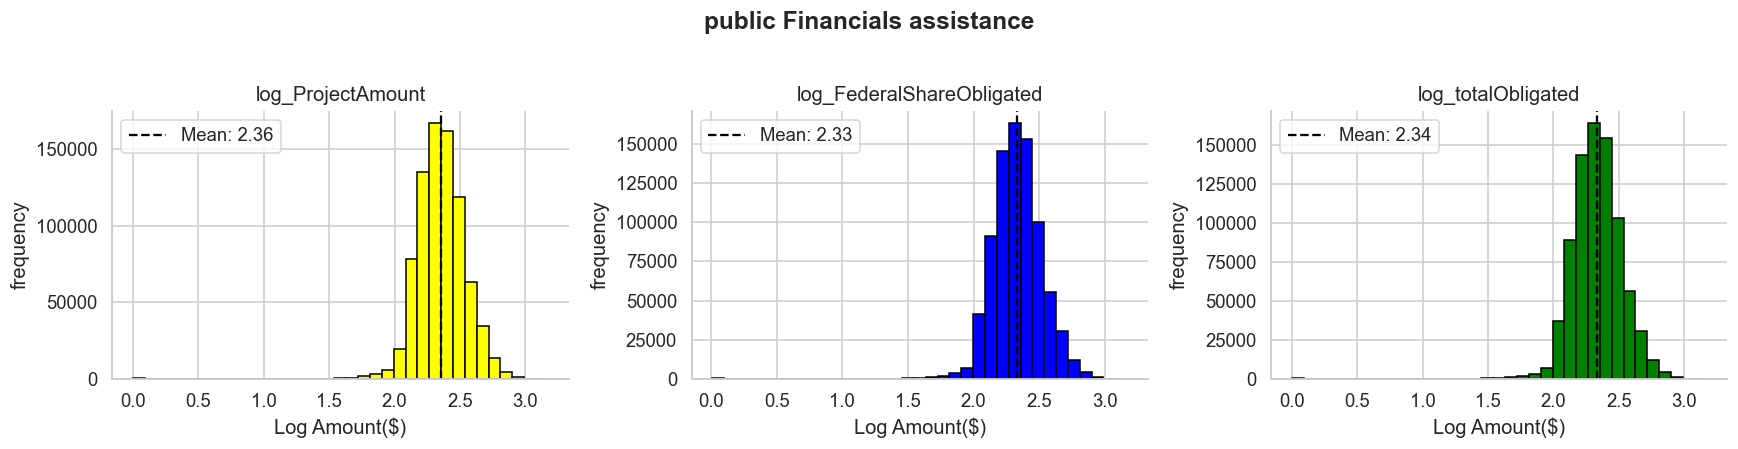

In [ ]:
# STEP 5a - Public Assistance Funding Distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title, color in zip(
    axes,
    ["log_projectAmount", "log_federalShareObligated" , "log_totalObligated"],
    ["log_ProjectAmount", "log_FederalShareObligated", "log_totalObligated"],
    ["yellow", "blue" , "green"]
    ):

    #step  filter out negative valuues
    data = public_assistance.loc[
        public_assistance[col]>=0,
        col
    ]

    #   log transform
    data = np.log1p(data)

    #  plot the distribution
    ax.hist(data, bins=35, color=color, edgecolor="black")
    ax.axvline(
        data.mean(), color="black", linestyle="dashed",
        label=f"Mean: {data.mean():.2f}"
    )
    ax.set(title=title, xlabel="Log Amount($)", ylabel="frequency")
    ax.legend()

plt.suptitle("public Financials assistance", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

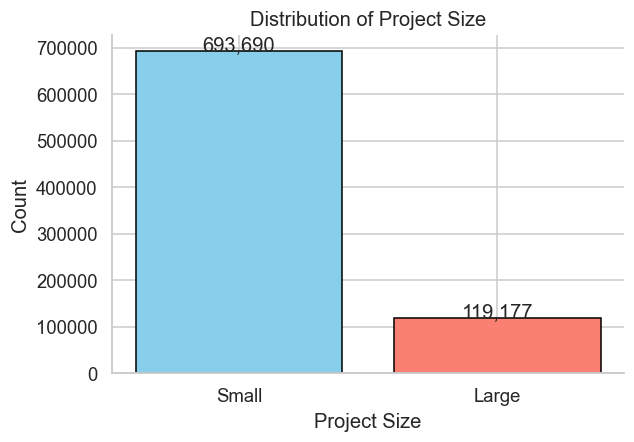

In [37]:
# STEP 5b - Large vs Small Public Assistance Projects
project_size_counts = (
    public_assistance["projectSize"]
    .value_counts()
)

plt.figure(figsize=(6,4))

plt.bar(
    project_size_counts.index,
    project_size_counts.values,
    color=["skyblue", "salmon"],
    edgecolor="black"
)

for i, v in enumerate(project_size_counts.values):
    plt.text(
        i,
        v,
        f"{v:,}",
        ha="center"
    )

plt.title("Distribution of Project Size")
plt.xlabel("Project Size")
plt.ylabel("Count")

plt.show()

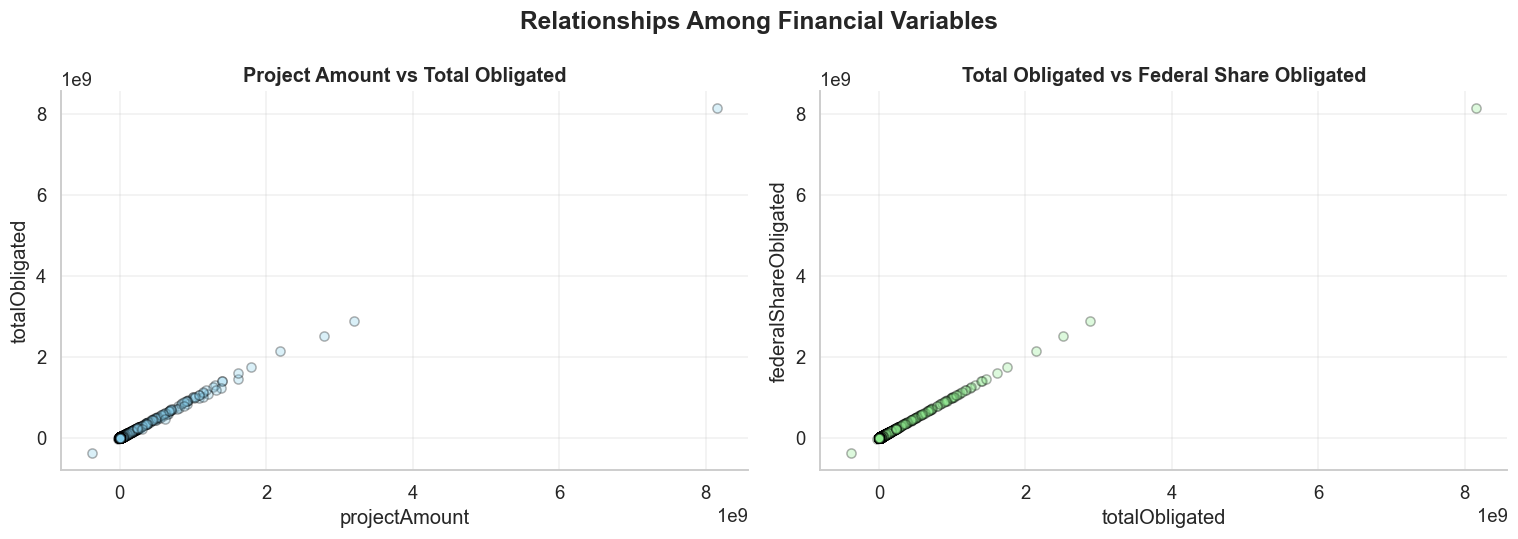

In [39]:
# STEP 5c - Funding Relationship
fig, axes = plt.subplots(
    1,2,figsize=(14,5))

variables = [

    ("projectAmount", "totalObligated",
     "Project Amount vs Total Obligated",
     "skyblue"),

    ("totalObligated", "federalShareObligated",
     "Total Obligated vs Federal Share Obligated",
     "lightgreen")
]

for ax, (x, y, title, color) in zip(
    axes,
    variables
):

    ax.scatter(
        public_assistance[x],
        public_assistance[y],
        alpha=0.3,
        color=color,
        edgecolors="black"
    )

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(x)
    ax.set_ylabel(y)

    ax.grid(alpha=0.3)

plt.suptitle(
    "Relationships Among Financial Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### STEP 6 - Disaster Summaries Dataset Analysis

In [41]:


disaster_summaries.head()
print(f"Shape: {disaster_summaries.shape}")
print(disaster_summaries.dtypes)
print(disaster_summaries.isnull().sum())

Shape: (3945, 11)
disasterNumber                  int64
totalNumberIaApproved         float64
totalAmountIhpApproved        float64
totalAmountHaApproved         float64
totalAmountOnaApproved        float64
totalObligatedAmountPa        float64
totalObligatedAmountCatAb     float64
totalObligatedAmountCatC2g    float64
totalObligatedAmountHmgp      float64
paLoadDate                        str
iaLoadDate                        str
dtype: object
disasterNumber                   0
totalNumberIaApproved         3339
totalAmountIhpApproved        3339
totalAmountHaApproved         3395
totalAmountOnaApproved        3341
totalObligatedAmountPa         956
totalObligatedAmountCatAb     1217
totalObligatedAmountCatC2g    2389
totalObligatedAmountHmgp      1102
paLoadDate                     956
iaLoadDate                    3339
dtype: int64


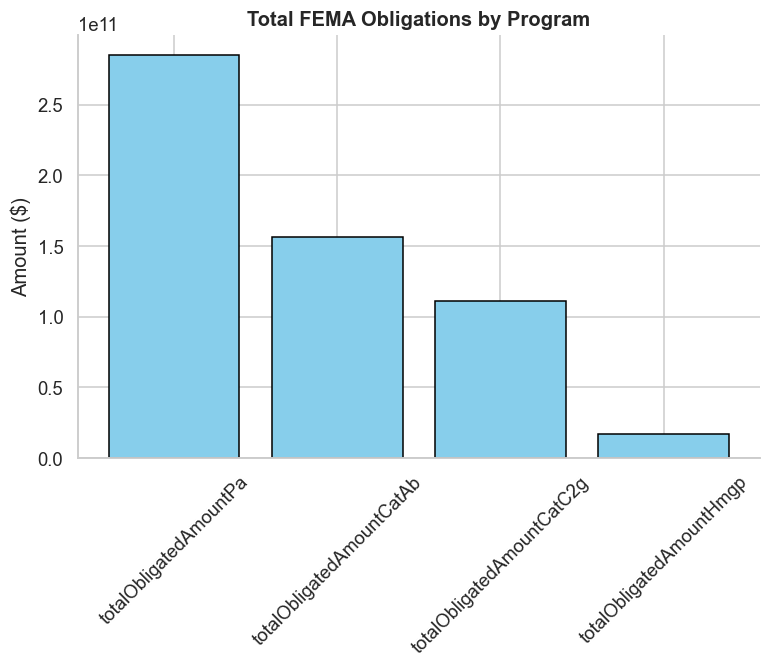

In [43]:
# STEP 6a - Disaster Summary Amounts and Registrations

summary_cols = [
    "totalObligatedAmountPa",
    "totalObligatedAmountCatAb",
    "totalObligatedAmountCatC2g",
    "totalObligatedAmountHmgp"
]


program_totals = disaster_summaries[
    summary_cols
].sum()

plt.figure(figsize=(8,5))

plt.bar(
    program_totals.index,
    program_totals.values,
    color="skyblue",
    edgecolor="black"
)

plt.title(
    "Total FEMA Obligations by Program",
    fontweight="bold"
)

plt.ylabel("Amount ($)")
plt.xticks(rotation=45)

plt.show()

### STEP 7 - Cross Dataset Business Summary


In [45]:

print("FEMA EDA Summary")
print("-" * 50)

if "state" in declarations.columns:
    print(f"Top declaration state: {declarations['state'].value_counts().idxmax()}")

if "incidentType" in declarations.columns:
    print(f"Most common incident type: {declarations['incidentType'].value_counts().idxmax()}")

if "declarationType" in declarations.columns:
    print(f"Most common declaration type: {declarations['declarationType'].value_counts().idxmax()}")

if "projectAmount" in public_assistance.columns:
    print(f"Average PA project amount: ${public_assistance['projectAmount'].mean():,.2f}")

if "totalObligated" in public_assistance.columns:
    print(f"Average total obligated amount: ${public_assistance['totalObligated'].mean():,.2f}")

if "totalObligatedAmountPa" in disaster_summaries.columns:
    print(f"Average PA obligated amount from summaries: ${disaster_summaries['totalObligatedAmountPa'].mean():,.2f}")

FEMA EDA Summary
--------------------------------------------------
Top declaration state: TX
Most common incident type: Severe Storm
Most common declaration type: DR
Average PA project amount: $374,482.93
Average total obligated amount: $348,892.66
Average PA obligated amount from summaries: $95,454,461.41
